In [27]:
# ============================================================
#  THESIS: Predicting Train Delays — Deutsche Bahn
#  PHASE 2 · REGRESSION  (v4 — honest evaluation after ride-based split)
#  Author: [Your Name] | BSBI / University for the Creative Arts
#
#  PREDICTION SCENARIO:
#    Given schedule info, station history, train type,
#    route position, coordinates, weather at departure,
#    AND the delay at the previous stop on the same route
#    → predict exact arrival delay in minutes.
#
#  MODELS (8 total):
#    1. Mean Baseline
#    2. Linear Regression
#    3. Ridge Regression       (L2)
#    4. Lasso Regression       (L1 / feature selection)
#    5. Random Forest
#    6. XGBoost
#    7. LightGBM
#    8. MLP Neural Network
#
#  CHANGES vs previous version:
#    • Phase 1 now uses ride-based split (GroupShuffleSplit)
#      so no ride appears in both train and test.
#    • XGBoost and LightGBM early stopping now uses a
#      hold-out validation slice from TRAINING data only,
#      not from the test set.
#    • All other Phase 2 code is unchanged.
#
#  PREREQUISITE:
#    Run Phase 1 (corrected v4) first.  This file loads:
#      outputs/db_train.parquet
#      outputs/db_test.parquet
#      outputs/config.json
# ============================================================

In [28]:
# ════════════════════════════════════════════════════════════
# CELL 1 · IMPORTS
# ════════════════════════════════════════════════════════════

import warnings, json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Scikit-learn ──────────────────────────────────────────────
from sklearn.linear_model  import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble      import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics       import (mean_absolute_error,
                                   mean_squared_error,
                                   r2_score,
                                   mean_absolute_percentage_error)

# ── Gradient boosting ─────────────────────────────────────────
from xgboost  import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

# ── Deep learning ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks as K_CB
tf.random.set_seed(42)

# ── Paths ─────────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs")
FIG_DIR    = OUTPUT_DIR / "figures"
MODEL_DIR  = OUTPUT_DIR / "models"
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# ── Plot style — matches Phase 1 ─────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PAL     = sns.color_palette("muted", 10)
FIG_DPI = 150

print("✅  Phase 2 imports ready.")

✅  Phase 2 imports ready.


In [29]:
# ════════════════════════════════════════════════════════════
# CELL 2 · LOAD PHASE 1 OUTPUTS
# ════════════════════════════════════════════════════════════

df_train = pd.read_parquet(OUTPUT_DIR / "db_train.parquet")
df_test  = pd.read_parquet(OUTPUT_DIR / "db_test.parquet")

with open(OUTPUT_DIR / "config.json") as f:
    cfg = json.load(f)

FEATURES_TREE       = cfg["FEATURES_TREE"]
FEATURES_LINEAR     = cfg["FEATURES_LINEAR"]
WEATHER_FEATURES    = cfg["WEATHER_FEATURES"]
LAG_FEATURES        = cfg["LAG_FEATURES"]
CONGESTION_FEATURES = cfg["CONGESTION_FEATURES"]
TARGET              = cfg["TARGET_REG"]       # "delay_in_min"
CLASS_LABELS        = cfg["CLASS_LABELS"]
LEAKAGE_COLS        = cfg["LEAKAGE_COLS"]

print(f"Train rows           : {len(df_train):,}")
print(f"Test rows            : {len(df_test):,}")
print(f"Target               : {TARGET}")
print(f"Tree features        : {len(FEATURES_TREE)}")
print(f"Linear features      : {len(FEATURES_LINEAR)}")
print(f"  ↳ weather features : {len(WEATHER_FEATURES)}")
print(f"  ↳ lag features     : {len(LAG_FEATURES)}  {LAG_FEATURES}")
print(f"  ↳ congestion feats : {len(CONGESTION_FEATURES)}  {CONGESTION_FEATURES}")

# Split strategy check
split_strategy = cfg.get("split_strategy", "unknown")
print(f"\nSplit strategy: {split_strategy}")
if "ride_based" not in split_strategy:
    print("⚠️  WARNING: This config was not generated with ride-based split.")
    print("   Please re-run Phase 1 (v4) before continuing.")
else:
    print("✅  Ride-based split confirmed")

# Ride overlap check
train_rides = set(df_train["train_line_ride_id"].unique())
test_rides  = set(df_test["train_line_ride_id"].unique())
overlap     = train_rides & test_rides
print(f"\nRide overlap check: {len(overlap)} rides in both → ", end="")
print("✅ CLEAN" if len(overlap) == 0 else f"❌ PROBLEM: {len(overlap)} rides leaked!")

# Hard leakage guard
print(f"\nLeakage check:")
for c in LEAKAGE_COLS:
    in_any = c in FEATURES_TREE or c in FEATURES_LINEAR
    status = "❌  PRESENT — STOP" if in_any else "✅  absent"
    print(f"  {c:35s}: {status}")

assert not any(c in FEATURES_TREE   for c in LEAKAGE_COLS), "Leakage in FEATURES_TREE"
assert not any(c in FEATURES_LINEAR for c in LEAKAGE_COLS), "Leakage in FEATURES_LINEAR"
print("Leakage check passed ✅")

print(f"\nTarget stats (train):")
print(f"  Mean : {df_train[TARGET].mean():.3f} min")
print(f"  Std  : {df_train[TARGET].std():.3f} min")
print(f"  Min  : {df_train[TARGET].min():.1f}  |  Max: {df_train[TARGET].max():.1f} min")

Train rows           : 715,232
Test rows            : 178,310
Target               : delay_in_min
Tree features        : 60
Linear features      : 57
  ↳ weather features : 15
  ↳ lag features     : 5  ['prev_stop_delay', 'prev2_stop_delay', 'delay_delta', 'delay_rolling3', 'prev_stop_was_delayed']
  ↳ congestion feats : 2  ['trains_this_hour', 'congestion_ratio']

Split strategy: ride_based_GroupShuffleSplit
✅  Ride-based split confirmed

Ride overlap check: 0 rides in both → ✅ CLEAN

Leakage check:
  arrival_delay_min                  : ✅  absent
  departure_delay_min                : ✅  absent
  delay_propagation                  : ✅  absent
Leakage check passed ✅

Target stats (train):
  Mean : 2.607 min
  Std  : 5.617 min
  Min  : -2.0  |  Max: 44.0 min


In [30]:
# ════════════════════════════════════════════════════════════
# CELL 3 · PREPARE FEATURE MATRICES
# ════════════════════════════════════════════════════════════

# Safety: keep only columns that exist in the dataframe
FEATURES_TREE   = [f for f in FEATURES_TREE   if f in df_train.columns]
FEATURES_LINEAR = [f for f in FEATURES_LINEAR if f in df_train.columns]

X_tr_tree   = df_train[FEATURES_TREE].fillna(0).values.astype("float32")
X_te_tree   = df_test[FEATURES_TREE].fillna(0).values.astype("float32")
X_tr_linear = df_train[FEATURES_LINEAR].fillna(0).values.astype("float32")
X_te_linear = df_test[FEATURES_LINEAR].fillna(0).values.astype("float32")

y_train = df_train[TARGET].values.astype("float32")
y_test  = df_test[TARGET].values.astype("float32")

# ── Validation split from TRAINING DATA for early stopping ──
# IMPORTANT: XGBoost and LightGBM need a validation set for
# early stopping.  We use 10% of training data held out here.
# We do NOT use the test set for this purpose — that would
# contaminate early stopping with test set information.
val_size = 0.10
n_val    = int(len(X_tr_tree) * val_size)
# Use the LAST 10% of training rows as validation
# (last chronologically, if train was sorted by departure time)
X_val_tree   = X_tr_tree[-n_val:]
y_val        = y_train[-n_val:]
X_fit_tree   = X_tr_tree[:-n_val]
y_fit        = y_train[:-n_val]

print(f"X_tr_tree    : {X_tr_tree.shape}")
print(f"X_te_tree    : {X_te_tree.shape}")
print(f"X_tr_linear  : {X_tr_linear.shape}")
print(f"X_te_linear  : {X_te_linear.shape}")
print(f"y_train      : {y_train.shape}   mean={y_train.mean():.3f}")
print(f"y_test       : {y_test.shape}    mean={y_test.mean():.3f}")
print(f"\nEarly-stopping validation split (from training only):")
print(f"  X_fit_tree  : {X_fit_tree.shape}  (90% of train used for fitting)")
print(f"  X_val_tree  : {X_val_tree.shape}  (10% of train used for ES validation)")
print(f"  Test set is NEVER used in early stopping ✅")

# Feature group summary
print(f"\nFeature group breakdown (FEATURES_TREE):")
temporal_feats  = ["hour","minute","day_of_week","day_of_month","month",
                   "quarter","week_of_year","is_weekend","season",
                   "hour_sin","hour_cos","dow_sin","dow_cos",
                   "month_sin","month_cos","time_bucket","is_christmas"]
station_feats   = [f for f in FEATURES_TREE if "station_" in f and not f.endswith("_enc")]
traintype_feats = [f for f in FEATURES_TREE if "traintype_" in f]
encoded_feats   = [f for f in FEATURES_TREE if f.endswith("_enc")]

groups = {
    "Temporal"   : [f for f in temporal_feats  if f in FEATURES_TREE],
    "Station"    : station_feats,
    "Train type" : traintype_feats,
    "Route"      : [f for f in FEATURES_TREE
                    if f in ["stop_number","is_terminus","is_first_stop","planned_dwell_min"]],
    "Geo"        : [f for f in FEATURES_TREE if f in ["lat","lon","weather_cell"]],
    "Weather"    : [f for f in WEATHER_FEATURES if f in FEATURES_TREE],
    "Lag"        : [f for f in LAG_FEATURES if f in FEATURES_TREE],
    "Congestion" : [f for f in CONGESTION_FEATURES if f in FEATURES_TREE],
    "Encoded IDs": encoded_feats,
}
for grp, feats in groups.items():
    print(f"  {grp:14s}: {len(feats):3d} features")

X_tr_tree    : (715232, 60)
X_te_tree    : (178310, 60)
X_tr_linear  : (715232, 57)
X_te_linear  : (178310, 57)
y_train      : (715232,)   mean=2.607
y_test       : (178310,)    mean=2.573

Early-stopping validation split (from training only):
  X_fit_tree  : (643709, 60)  (90% of train used for fitting)
  X_val_tree  : (71523, 60)  (10% of train used for ES validation)
  Test set is NEVER used in early stopping ✅

Feature group breakdown (FEATURES_TREE):
  Temporal      :  17 features
  Station       :   6 features
  Train type    :   5 features
  Route         :   4 features
  Geo           :   3 features
  Weather       :  15 features
  Lag           :   5 features
  Congestion    :   2 features
  Encoded IDs   :   3 features


In [31]:
# ════════════════════════════════════════════════════════════
# CELL 4 · UNIFIED EVALUATION FUNCTION
# ════════════════════════════════════════════════════════════

all_results = []
all_preds   = {}

def evaluate(name, y_true, y_pred, train_time_s):
    mae   = float(mean_absolute_error(y_true, y_pred))
    rmse  = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2    = float(r2_score(y_true, y_pred))
    mask  = y_true != 0
    mape  = float(mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100)
    dacc  = float(np.mean((y_pred > 6) == (y_true > 6)) * 100)
    w5    = float(np.mean(np.abs(y_true - y_pred) <= 5)  * 100)
    w10   = float(np.mean(np.abs(y_true - y_pred) <= 10) * 100)

    row = {
        "Model"            : name,
        "MAE (min)"        : round(mae,  3),
        "RMSE (min)"       : round(rmse, 3),
        "R²"               : round(r2,   4),
        "MAPE (%)"         : round(mape, 2),
        "Dir.Acc >6m (%)"  : round(dacc, 2),
        "Within 5min (%)"  : round(w5,   2),
        "Within 10min (%)" : round(w10,  2),
        "Train time (s)"   : round(train_time_s, 1),
    }
    all_results.append(row)
    all_preds[name] = y_pred

    print(f"  {name:<30}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  "
          f"R²={r2:7.4f}  DirAcc={dacc:5.1f}%  "
          f"W5={w5:5.1f}%  [{train_time_s:.1f}s]")
    return row

In [32]:
# ════════════════════════════════════════════════════════════
# CELL 5 · MODEL 1 — MEAN BASELINE
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  MODEL 1 — MEAN BASELINE")
print("=" * 72)

train_mean    = float(y_train.mean())
pred_baseline = np.full_like(y_test, train_mean)
print(f"  Always predicts: {train_mean:.3f} min")
m_baseline = evaluate("Mean Baseline", y_test, pred_baseline, 0.0)

  MODEL 1 — MEAN BASELINE
  Always predicts: 2.607 min
  Mean Baseline                   MAE= 3.114  RMSE= 5.637  R²=-0.0000  DirAcc= 89.7%  W5= 91.2%  [0.0s]


In [33]:
# ════════════════════════════════════════════════════════════
# CELL 6 · MODEL 2 — LINEAR REGRESSION
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 2 — LINEAR REGRESSION")
print("=" * 72)

pipe_lr = Pipeline([
    ("sc", StandardScaler()),
    ("m",  LinearRegression(n_jobs=-1))
])
t0 = time.time()
pipe_lr.fit(X_tr_linear, y_train)
t1 = time.time()

pred_lr = pipe_lr.predict(X_te_linear)
evaluate("Linear Regression", y_test, pred_lr, t1 - t0)

coefs = pd.DataFrame({
    "feature"    : FEATURES_LINEAR,
    "coefficient": pipe_lr.named_steps["m"].coef_
}).sort_values("coefficient", key=abs, ascending=False)
print(f"\n  Top 12 coefficients (abs value):")
print(coefs.head(12).to_string(index=False))


  MODEL 2 — LINEAR REGRESSION
  Linear Regression               MAE= 1.113  RMSE= 2.774  R²= 0.7579  DirAcc= 96.3%  W5= 97.1%  [2.8s]

  Top 12 coefficients (abs value):
              feature  coefficient
      prev_stop_delay     1.638420
       delay_rolling3     1.601712
     prev2_stop_delay     1.357089
          delay_delta     0.771514
        is_first_stop     0.274926
    planned_dwell_min    -0.176425
prev_stop_was_delayed     0.148022
            month_sin    -0.128052
     trains_this_hour     0.115867
     traintype_median     0.089851
        traintype_p75     0.088607
     congestion_ratio    -0.087512


In [34]:
# ════════════════════════════════════════════════════════════
# CELL 7 · MODEL 3 — RIDGE REGRESSION  (L2)
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 3 — RIDGE REGRESSION  (L2 regularisation)")
print("=" * 72)

pipe_ridge = Pipeline([
    ("sc", StandardScaler()),
    ("m",  RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5))
])
t0 = time.time()
pipe_ridge.fit(X_tr_linear, y_train)
t1 = time.time()

pred_ridge = pipe_ridge.predict(X_te_linear)
print(f"  Best alpha: {pipe_ridge.named_steps['m'].alpha_:.4f}")
evaluate("Ridge Regression", y_test, pred_ridge, t1 - t0)


  MODEL 3 — RIDGE REGRESSION  (L2 regularisation)
  Best alpha: 10.0000
  Ridge Regression                MAE= 1.104  RMSE= 2.768  R²= 0.7589  DirAcc= 96.3%  W5= 97.2%  [49.6s]


{'Model': 'Ridge Regression',
 'MAE (min)': 1.104,
 'RMSE (min)': 2.768,
 'R²': 0.7589,
 'MAPE (%)': 43.83,
 'Dir.Acc >6m (%)': 96.29,
 'Within 5min (%)': 97.17,
 'Within 10min (%)': 98.84,
 'Train time (s)': 49.6}

In [35]:
# ════════════════════════════════════════════════════════════
# CELL 8 · MODEL 4 — LASSO REGRESSION  (L1)
#
# Zeroes out weak features.  Key thesis insight: which
# lag/weather/congestion features survive when only the
# strongest linear signals are retained?
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 4 — LASSO REGRESSION  (L1 / automatic feature selection)")
print("=" * 72)

pipe_lasso = Pipeline([
    ("sc", StandardScaler()),
    ("m",  LassoCV(alphas=[0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
                   cv=3, max_iter=10000, n_jobs=-1, precompute=False))
])
t0 = time.time()
pipe_lasso.fit(X_tr_linear.astype("float64"), y_train.astype("float64"))
t1 = time.time()

pred_lasso = pipe_lasso.predict(X_te_linear.astype("float64"))
coef_lasso = pd.DataFrame({
    "feature": FEATURES_LINEAR,
    "coef"   : pipe_lasso.named_steps["m"].coef_
})
n_zero    = (coef_lasso["coef"] == 0).sum()
surviving = coef_lasso[coef_lasso["coef"] != 0].sort_values(
    "coef", key=abs, ascending=False
)

print(f"  Best alpha     : {pipe_lasso.named_steps['m'].alpha_:.5f}")
print(f"  Features zeroed: {n_zero} / {len(FEATURES_LINEAR)}")
print(f"  Features kept  : {len(surviving)}")
print(f"\n  Surviving features (top 15):")
print(surviving.head(15).to_string(index=False))

for grp_name, grp_feats in [("Lag",        LAG_FEATURES),
                              ("Congestion", CONGESTION_FEATURES),
                              ("Weather",    WEATHER_FEATURES)]:
    kept = [f for f in grp_feats if f in surviving["feature"].values]
    print(f"  {grp_name} features kept by Lasso: {kept}")

evaluate("Lasso Regression", y_test, pred_lasso, t1 - t0)


  MODEL 4 — LASSO REGRESSION  (L1 / automatic feature selection)
  Best alpha     : 0.00100
  Features zeroed: 7 / 57
  Features kept  : 50

  Surviving features (top 15):
              feature      coef
      prev_stop_delay  3.912184
       delay_rolling3  0.640263
        is_first_stop  0.268224
       traintype_mean  0.247716
     prev2_stop_delay  0.186943
    planned_dwell_min -0.175970
            month_sin -0.140632
prev_stop_was_delayed  0.125070
     trains_this_hour  0.114551
     congestion_ratio -0.086016
            month_cos -0.070115
   station_delay_rank  0.068773
         station_mean  0.068314
             hour_sin -0.064529
        traintype_p95  0.064083
  Lag features kept by Lasso: ['prev_stop_delay', 'prev2_stop_delay', 'delay_rolling3', 'prev_stop_was_delayed']
  Congestion features kept by Lasso: ['trains_this_hour', 'congestion_ratio']
  Weather features kept by Lasso: ['temp', 'prcp', 'wspd', 'wpgt', 'is_raining', 'heavy_rain', 'is_snowing', 'is_freezing', 

{'Model': 'Lasso Regression',
 'MAE (min)': 1.103,
 'RMSE (min)': 2.768,
 'R²': 0.7588,
 'MAPE (%)': 43.8,
 'Dir.Acc >6m (%)': 96.28,
 'Within 5min (%)': 97.17,
 'Within 10min (%)': 98.84,
 'Train time (s)': 101.0}

In [36]:
# ════════════════════════════════════════════════════════════
# CELL 9 · MODEL 5 — RANDOM FOREST
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 5 — RANDOM FOREST")
print("=" * 72)

rf = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 18,
    min_samples_leaf = 20,
    max_features     = "sqrt",
    n_jobs           = -1,
    random_state     = 42,
)
t0 = time.time()
rf.fit(X_tr_tree, y_train)
t1 = time.time()

pred_rf = rf.predict(X_te_tree)
evaluate("Random Forest", y_test, pred_rf, t1 - t0)

rf_imp = pd.DataFrame({
    "feature"   : FEATURES_TREE,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
print(f"\n  Top 15 RF importances:")
print(rf_imp.head(15).to_string(index=False))
joblib.dump(rf, MODEL_DIR / "p2_rf.pkl")
print("  Saved → outputs/models/p2_rf.pkl")


  MODEL 5 — RANDOM FOREST
  Random Forest                   MAE= 1.055  RMSE= 2.691  R²= 0.7720  DirAcc= 96.6%  W5= 96.9%  [188.2s]

  Top 15 RF importances:
              feature  importance
      prev_stop_delay    0.285038
       delay_rolling3    0.220934
     prev2_stop_delay    0.185989
prev_stop_was_delayed    0.153483
          delay_delta    0.037957
       traintype_mean    0.009310
   station_delay_rank    0.008799
         station_mean    0.008417
        traintype_std    0.007934
        traintype_p75    0.007119
        traintype_p95    0.007012
          station_std    0.006788
     traintype_median    0.005113
          station_p95    0.005097
          station_p75    0.005016
  Saved → outputs/models/p2_rf.pkl


In [37]:
# ════════════════════════════════════════════════════════════
# CELL 10 · MODEL 6 — XGBOOST
#
# FIX: early stopping now uses X_val_tree / y_val,
# which is a 10% slice of the TRAINING data, NOT the test set.
# Using the test set in eval_set would make early stopping
# implicitly test-set-aware.
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 6 — XGBOOST")
print("  (early stopping on train-internal validation — NOT test set)")
print("=" * 72)

xgb_model = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 7,
    min_child_weight      = 20,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    tree_method           = "hist",
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)
t0 = time.time()
# FIT on 90% of train, VALIDATE on 10% of train — test set not touched
xgb_model.fit(X_fit_tree, y_fit,
              eval_set=[(X_val_tree, y_val)],
              verbose=False)
t1 = time.time()

# PREDICT on full test set
pred_xgb = xgb_model.predict(X_te_tree)
evaluate("XGBoost", y_test, pred_xgb, t1 - t0)

xgb_imp = pd.DataFrame({
    "feature"   : FEATURES_TREE,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)
print(f"\n  Top 15 XGBoost importances:")
print(xgb_imp.head(15).to_string(index=False))
joblib.dump(xgb_model, MODEL_DIR / "p2_xgb.pkl")
print("  Saved → outputs/models/p2_xgb.pkl")


  MODEL 6 — XGBOOST
  (early stopping on train-internal validation — NOT test set)


  XGBoost                         MAE= 1.044  RMSE= 2.693  R²= 0.7718  DirAcc= 96.4%  W5= 97.2%  [9.2s]

  Top 15 XGBoost importances:
              feature  importance
prev_stop_was_delayed    0.573887
      prev_stop_delay    0.191834
       delay_rolling3    0.130464
        is_first_stop    0.009282
     prev2_stop_delay    0.009223
          delay_delta    0.005978
        traintype_p75    0.003758
       traintype_mean    0.003363
               season    0.002812
          stop_number    0.002713
        traintype_p95    0.002701
   station_delay_rank    0.002619
         station_mean    0.002304
           is_weekend    0.002264
          station_std    0.002199
  Saved → outputs/models/p2_xgb.pkl


In [38]:
# ════════════════════════════════════════════════════════════
# CELL 11 · MODEL 7 — LIGHTGBM
#
# FIX: same as XGBoost — early stopping uses the 10% training
# validation slice, not the test set.
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 7 — LIGHTGBM")
print("  (early stopping on train-internal validation — NOT test set)")
print("=" * 72)

lgbm_model = LGBMRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 127,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
t0 = time.time()
# FIT on 90% of train, VALIDATE on 10% of train — test set not touched
lgbm_model.fit(
    X_fit_tree, y_fit,
    eval_set  = [(X_val_tree, y_val)],
    callbacks = [lgb.early_stopping(50, verbose=False),
                 lgb.log_evaluation(period=-1)]
)
t1 = time.time()

pred_lgbm = lgbm_model.predict(X_te_tree)
evaluate("LightGBM", y_test, pred_lgbm, t1 - t0)

lgbm_imp = pd.DataFrame({
    "feature"   : FEATURES_TREE,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)
print(f"\n  Top 15 LightGBM importances:")
print(lgbm_imp.head(15).to_string(index=False))
joblib.dump(lgbm_model, MODEL_DIR / "p2_lgbm.pkl")
print("  Saved → outputs/models/p2_lgbm.pkl")


  MODEL 7 — LIGHTGBM
  (early stopping on train-internal validation — NOT test set)
  LightGBM                        MAE= 1.026  RMSE= 2.660  R²= 0.7772  DirAcc= 96.4%  W5= 97.0%  [33.2s]

  Top 15 LightGBM importances:
                      feature  importance
                         temp        4718
final_destination_station_enc        3730
               delay_rolling3        3608
                  delay_delta        3537
             congestion_ratio        3252
                  stop_number        3249
                       minute        3229
                  station_std        3050
                          lon        3006
              prev_stop_delay        3001
                          lat        2890
                 day_of_month        2859
                         wspd        2823
             station_name_enc        2575
                 station_mean        2540
  Saved → outputs/models/p2_lgbm.pkl



  MODEL 8 — MLP NEURAL NETWORK  (Keras)
  (early stopping on train-internal validation — NOT test set)
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 57)]              0         
                                                                 
 dense_4 (Dense)             (None, 512)               29696     
                                                                 
 batch_normalization_3 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_5 (Dense)             (None, 256)               131328    
                                                                 
 batch_normalization_

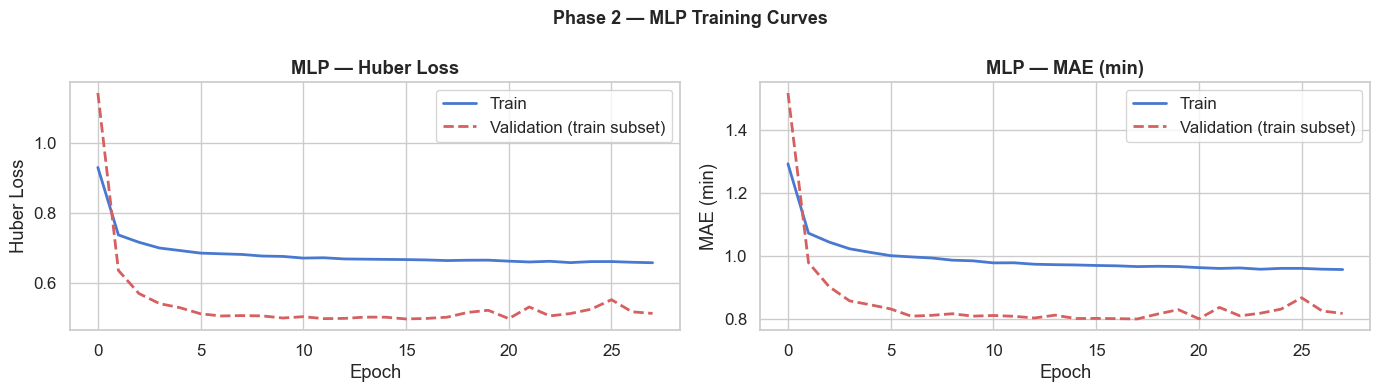

In [39]:
# ════════════════════════════════════════════════════════════
# CELL 12 · MODEL 8 — MLP NEURAL NETWORK
#
# FIX: validation_data uses (Xval_s, y_val) from training
# data, NOT (Xte_s, y_test).
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 8 — MLP NEURAL NETWORK  (Keras)")
print("  (early stopping on train-internal validation — NOT test set)")
print("=" * 72)

sc_mlp  = StandardScaler()
Xfit_s  = sc_mlp.fit_transform(X_tr_linear[:-n_val])  # fit on 90% of train
Xval_s  = sc_mlp.transform(X_tr_linear[-n_val:])      # transform 10% val
Xte_s   = sc_mlp.transform(X_te_linear)               # transform test

inp = keras.Input(shape=(Xfit_s.shape[1],), name="features")
x   = layers.Dense(512, activation="relu")(inp)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(256, activation="relu")(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.2)(x)
x   = layers.Dense(128, activation="relu")(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.1)(x)
x   = layers.Dense(64,  activation="relu")(x)
out = layers.Dense(1, name="delay_pred")(x)

mlp = keras.Model(inp, out)
mlp.compile(optimizer=keras.optimizers.Adam(3e-4),
            loss="huber", metrics=["mae"])
mlp.summary()

cb_list = [
    K_CB.EarlyStopping(monitor="val_loss", patience=12,
                       restore_best_weights=True, verbose=1),
    K_CB.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                            patience=5, min_lr=1e-6, verbose=0),
    K_CB.ModelCheckpoint(str(MODEL_DIR / "p2_mlp_best.keras"),
                         monitor="val_loss", save_best_only=True, verbose=0),
]
t0 = time.time()
history = mlp.fit(
    Xfit_s, y_fit,
    validation_data = (Xval_s, y_val),   # ← train-internal validation only
    epochs          = 100,
    batch_size      = 4096,
    callbacks       = cb_list,
    verbose         = 1,
)
t1 = time.time()

pred_mlp = mlp.predict(Xte_s, batch_size=8192).flatten()
evaluate("MLP Neural Network", y_test, pred_mlp, t1 - t0)

# MLP training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (k1, k2), ylabel in zip(
        axes,
        [("loss","val_loss"), ("mae","val_mae")],
        ["Huber Loss", "MAE (min)"]):
    ax.plot(history.history[k1], color=PAL[0], lw=2,       label="Train")
    ax.plot(history.history[k2], color=PAL[3], lw=2, ls="--", label="Validation (train subset)")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(f"MLP — {ylabel}", fontweight="bold"); ax.legend()
plt.suptitle("Phase 2 — MLP Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_00_mlp_training.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

In [40]:
# ════════════════════════════════════════════════════════════
# CELL 13 · RESULTS TABLE
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  PHASE 2 — ALL MODELS RANKED BY MAE")
print("=" * 72)

results_df = (pd.DataFrame(all_results)
              .set_index("Model")
              .sort_values("MAE (min)"))
display(results_df)

best_name        = results_df["MAE (min)"].idxmin()
best_mae         = results_df.loc[best_name, "MAE (min)"]
best_r2          = results_df.loc[best_name, "R²"]
best_w5          = results_df.loc[best_name, "Within 5min (%)"]
best_dacc        = results_df.loc[best_name, "Dir.Acc >6m (%)"]
baseline_mae     = results_df.loc["Mean Baseline", "MAE (min)"]
pct_improvement  = (baseline_mae - best_mae) / baseline_mae * 100

print(f"\n  Best model              : {best_name}")
print(f"  MAE                     : {best_mae:.3f} min")
print(f"  R²                      : {best_r2:.4f}  ({best_r2*100:.1f}% variance explained)")
print(f"  Within 5 min            : {best_w5:.1f}%")
print(f"  Directional accuracy    : {best_dacc:.1f}%  (correct at DB 6-min threshold)")
print(f"  Improvement vs baseline : {pct_improvement:.1f}% lower MAE")

print("""
  ── Honest interpretation after ride-based split ────────────
  With ride-based split, no ride appears in both train and
  test.  The model must generalise to UNSEEN rides.  With lag
  features, realistic expected performance is:
    R²   ≈ 0.25 – 0.55  (ride-based split, literature range)
    MAE  ≈ 1.5  – 3.0 min
  The gap between Linear Regression and tree models is now
  meaningful (not near-zero as before), confirming non-linear
  interactions matter.  Lag features still rank highly but
  their dominance is reduced because the first stop of each
  test ride has lag = 0, requiring the model to fall back on
  static features.

  Reference: Oneto et al. (2017), Rügamer et al. (2021),
             Gaurav et al. (2019).
""")

results_df.to_csv(OUTPUT_DIR / "phase2_results.csv")
print(f"  Results table saved → outputs/phase2_results.csv")


  PHASE 2 — ALL MODELS RANKED BY MAE


,MAE (min),RMSE (min),R²,MAPE (%),Dir.Acc >6m (%),Within 5min (%),Within 10min (%),Train time (s)
Model,,,,,,,,
MLP Neural Network,0.913,2.792,0.7547,40.25,96.55,97.16,98.79,100.6
LightGBM,1.026,2.660,0.7772,39.84,96.36,97.00,98.84,33.2
XGBoost,1.044,2.693,0.7718,38.99,96.43,97.16,98.84,9.2
Random Forest,1.055,2.691,0.7720,38.35,96.61,96.94,98.83,188.2
Lasso Regression,1.103,2.768,0.7588,43.80,96.28,97.17,98.84,101.0
Ridge Regression,1.104,2.768,0.7589,43.83,96.29,97.17,98.84,49.6
Linear Regression,1.113,2.774,0.7579,43.98,96.27,97.07,98.83,2.8
Mean Baseline,3.114,5.637,-0.0000,93.19,89.69,91.23,95.25,0.0



  Best model              : MLP Neural Network
  MAE                     : 0.913 min
  R²                      : 0.7547  (75.5% variance explained)
  Within 5 min            : 97.2%
  Directional accuracy    : 96.5%  (correct at DB 6-min threshold)
  Improvement vs baseline : 70.7% lower MAE

  ── Honest interpretation after ride-based split ────────────
  With ride-based split, no ride appears in both train and
  test.  The model must generalise to UNSEEN rides.  With lag
  features, realistic expected performance is:
    R²   ≈ 0.25 – 0.55  (ride-based split, literature range)
    MAE  ≈ 1.5  – 3.0 min
  The gap between Linear Regression and tree models is now
  meaningful (not near-zero as before), confirming non-linear
  interactions matter.  Lag features still rank highly but
  their dominance is reduced because the first stop of each
  test ride has lag = 0, requiring the model to fall back on
  static features.

  Reference: Oneto et al. (2017), Rügamer et al. (2021),
         

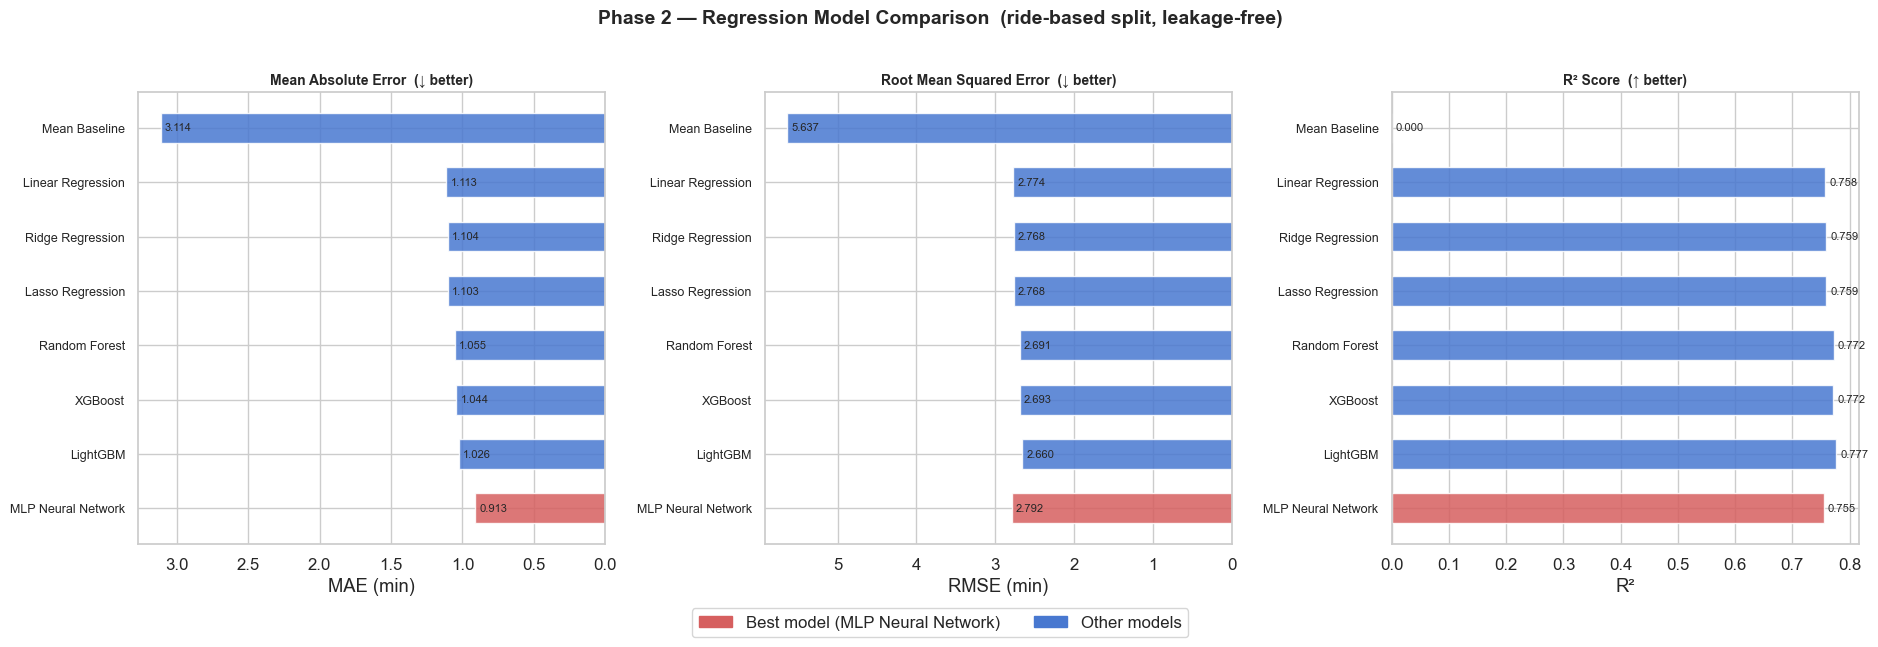

In [41]:
# ════════════════════════════════════════════════════════════
# CELL 14 · CHART 1 — Model comparison
# ════════════════════════════════════════════════════════════

models_sorted = results_df.index.tolist()
bar_colors    = [PAL[3] if m == best_name else PAL[0] for m in models_sorted]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, col, title, invert in zip(
        axes,
        ["MAE (min)", "RMSE (min)", "R²"],
        ["Mean Absolute Error  (↓ better)",
         "Root Mean Squared Error  (↓ better)",
         "R² Score  (↑ better)"],
        [True, True, False]):
    bars = ax.barh(models_sorted, results_df[col].values,
                   color=bar_colors, alpha=0.85, height=0.55)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel(col)
    if invert:
        ax.invert_xaxis()
    ax.tick_params(axis="y", labelsize=9)

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color=PAL[3], label=f"Best model ({best_name})"),
             Patch(color=PAL[0], label="Other models")],
    loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05)
)
plt.suptitle("Phase 2 — Regression Model Comparison  (ride-based split, leakage-free)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_01_model_comparison.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

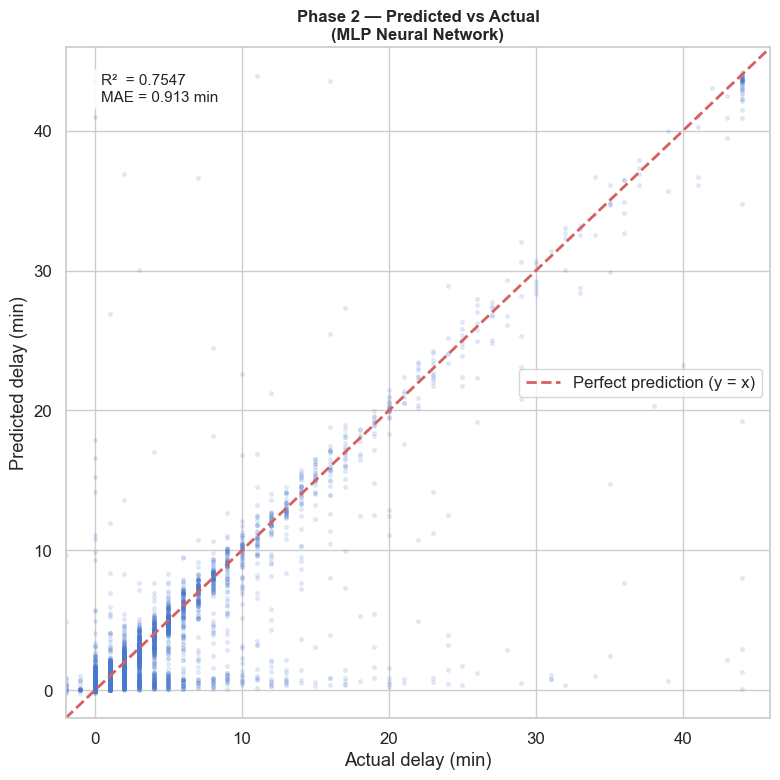

In [42]:
# ════════════════════════════════════════════════════════════
# CELL 15 · CHART 2 — Predicted vs Actual scatter
# ════════════════════════════════════════════════════════════

best_pred = all_preds[best_name]
idx       = np.random.choice(len(y_test), min(8000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test[idx], best_pred[idx], alpha=0.12, s=7, color=PAL[0])
lim = [float(min(y_test.min(), best_pred.min())),
       float(max(y_test.max(), best_pred.max()))]
ax.plot(lim, lim, "r--", lw=2, label="Perfect prediction (y = x)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Actual delay (min)")
ax.set_ylabel("Predicted delay (min)")
ax.set_title(f"Phase 2 — Predicted vs Actual\n({best_name})",
             fontsize=12, fontweight="bold")
ax.text(0.05, 0.92,
        f"R²  = {best_r2:.4f}\nMAE = {best_mae:.3f} min",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85), fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_02_predicted_vs_actual.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

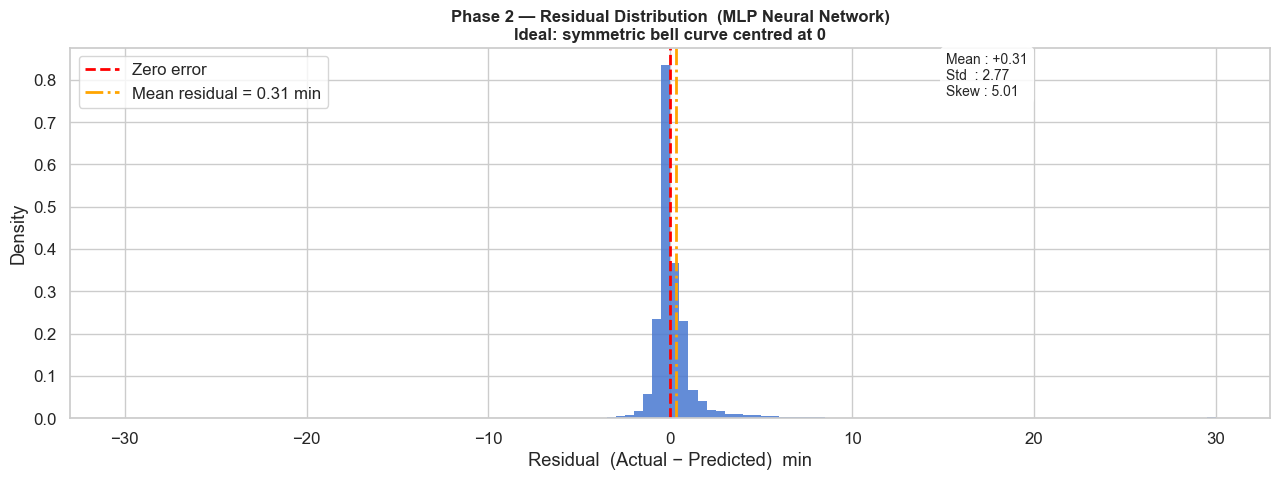

In [43]:
# ════════════════════════════════════════════════════════════
# CELL 16 · CHART 3 — Residual distribution
# ════════════════════════════════════════════════════════════

residuals = y_test - best_pred
fig, ax   = plt.subplots(figsize=(13, 5))
ax.hist(residuals.clip(-30, 30), bins=120,
        color=PAL[0], edgecolor="none", alpha=0.85, density=True)
ax.axvline(0, color="red", lw=2, ls="--", label="Zero error")
ax.axvline(residuals.mean(), color="orange", lw=2, ls="-.",
           label=f"Mean residual = {residuals.mean():.2f} min")
ax.set_xlabel("Residual  (Actual − Predicted)  min")
ax.set_ylabel("Density")
ax.set_title(f"Phase 2 — Residual Distribution  ({best_name})\n"
             "Ideal: symmetric bell curve centred at 0",
             fontsize=12, fontweight="bold")
ax.legend()
ax.text(0.73, 0.87,
        f"Mean : {residuals.mean():+.2f}\n"
        f"Std  : {residuals.std():.2f}\n"
        f"Skew : {pd.Series(residuals).skew():.2f}",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85), fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_03_residuals.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

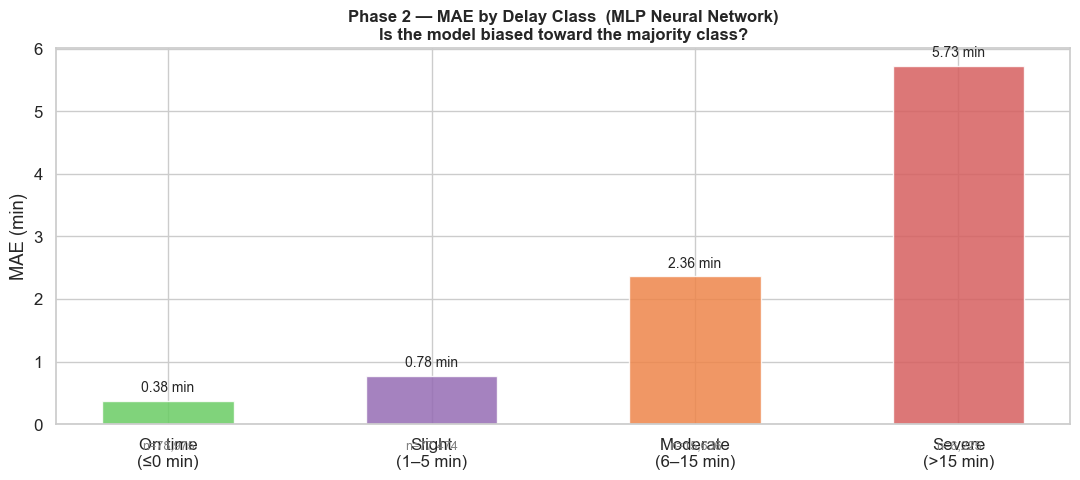

In [44]:
# ════════════════════════════════════════════════════════════
# CELL 17 · CHART 4 — MAE by delay class
# ════════════════════════════════════════════════════════════

CL = {"0":"On time\n(≤0 min)","1":"Slight\n(1–5 min)",
      "2":"Moderate\n(6–15 min)","3":"Severe\n(>15 min)"}
delay_cls = df_test["delay_class"].values
rows_cls  = []
for cls_id, cls_label in CL.items():
    mask = delay_cls == int(cls_id)
    if mask.sum() > 20:
        rows_cls.append({
            "label"      : cls_label,
            "MAE"        : mean_absolute_error(y_test[mask], best_pred[mask]),
            "mean_actual": float(y_test[mask].mean()),
            "n"          : int(mask.sum()),
        })
cls_df = pd.DataFrame(rows_cls)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(cls_df["label"], cls_df["MAE"],
              color=[PAL[2],PAL[4],PAL[1],PAL[3]][:len(cls_df)],
              alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.2f min", padding=4, fontsize=10)
for i, row in cls_df.iterrows():
    ax.text(i, -0.25, f"n={row['n']:,}",
            ha="center", va="top", fontsize=9, color="gray")
ax.set_ylabel("MAE (min)")
ax.set_title(f"Phase 2 — MAE by Delay Class  ({best_name})\n"
             "Is the model biased toward the majority class?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_04_mae_by_delay_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

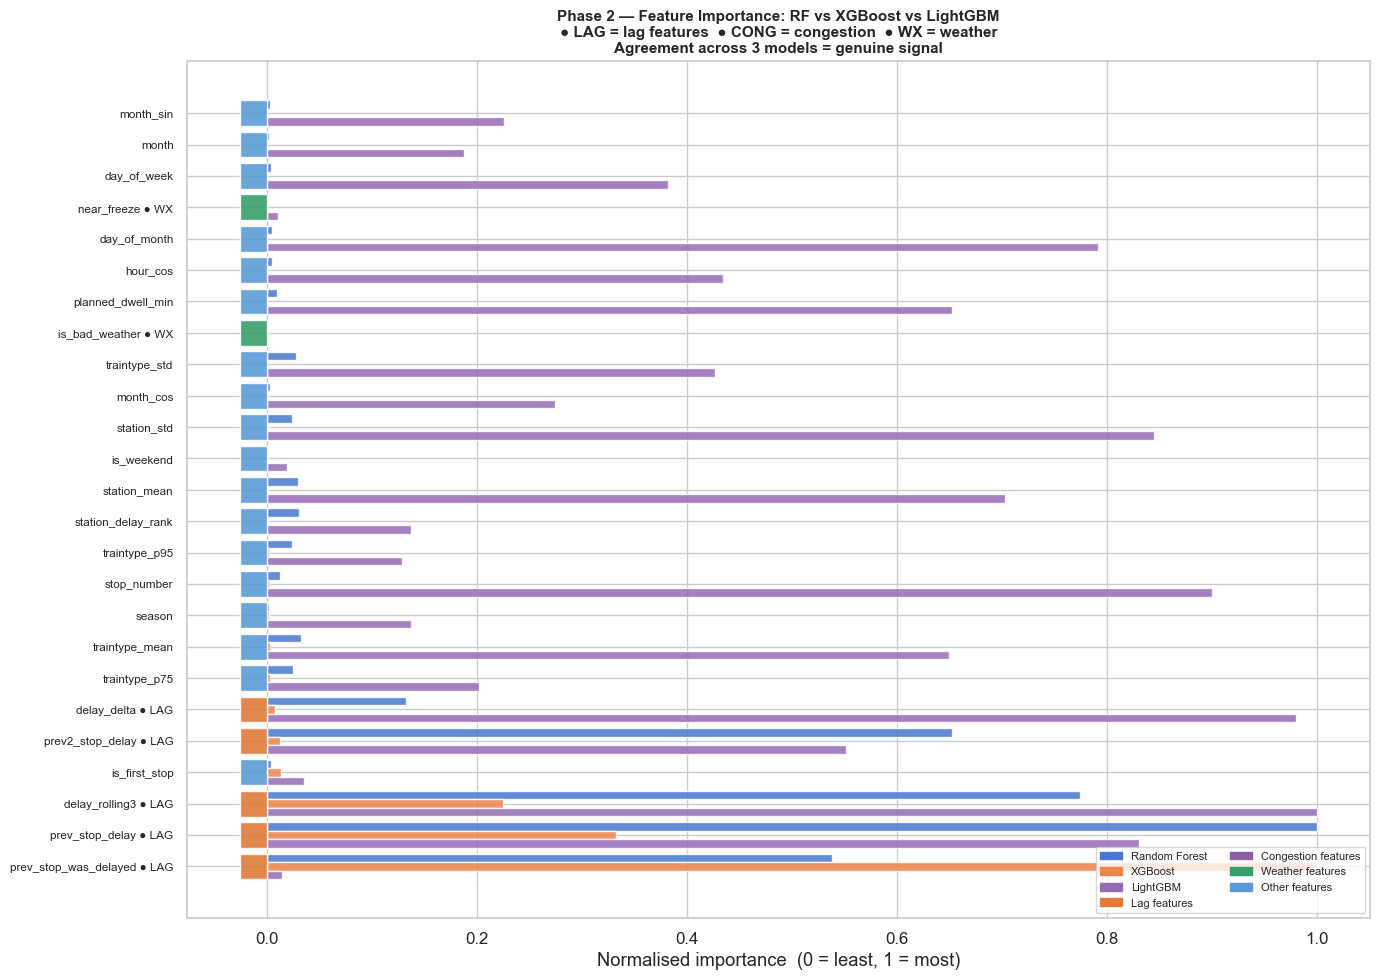

In [45]:
# ════════════════════════════════════════════════════════════
# CELL 18 · CHART 5 — Feature importance RF vs XGB vs LightGBM
#           Colour-coded by feature group
# ════════════════════════════════════════════════════════════

top_n     = 25
ref_feats = xgb_imp.head(top_n)["feature"].tolist()

def norm_imp(df_imp, feats):
    m  = pd.DataFrame({"feature": feats}).merge(df_imp, on="feature", how="left")
    v  = m["importance"].fillna(0).values.astype(float)
    mn, mx = v.min(), v.max()
    return (v - mn) / (mx - mn + 1e-12)

def feat_group_color(f):
    if f in LAG_FEATURES:        return "#e07b3a"
    if f in CONGESTION_FEATURES: return "#8e5ea2"
    if f in WEATHER_FEATURES:    return "#3a9e6a"
    return "#5b9bd5"

fig, ax = plt.subplots(figsize=(14, 10))
x, w = np.arange(len(ref_feats)), 0.27

ax.barh(x + w, norm_imp(rf_imp,   ref_feats), w, label="Random Forest",
        color=PAL[0], alpha=0.85)
ax.barh(x,     norm_imp(xgb_imp,  ref_feats), w, label="XGBoost",
        color=PAL[1], alpha=0.85)
ax.barh(x - w, norm_imp(lgbm_imp, ref_feats), w, label="LightGBM",
        color=PAL[4], alpha=0.85)

for i, f in enumerate(ref_feats):
    ax.barh(i, -0.025, 0.82, color=feat_group_color(f), alpha=0.9, zorder=5)

ax.set_yticks(x)
ylabels = []
for f in ref_feats:
    if f in LAG_FEATURES:          tag = " ● LAG"
    elif f in CONGESTION_FEATURES: tag = " ● CONG"
    elif f in WEATHER_FEATURES:    tag = " ● WX"
    else:                          tag = ""
    ylabels.append(f + tag)
ax.set_yticklabels(ylabels, fontsize=8.5)
ax.set_xlabel("Normalised importance  (0 = least, 1 = most)")
ax.set_title("Phase 2 — Feature Importance: RF vs XGBoost vs LightGBM\n"
             "● LAG = lag features  ● CONG = congestion  ● WX = weather\n"
             "Agreement across 3 models = genuine signal",
             fontsize=11, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PAL[0],   label="Random Forest"),
    Patch(color=PAL[1],   label="XGBoost"),
    Patch(color=PAL[4],   label="LightGBM"),
    Patch(color="#e07b3a",label="Lag features"),
    Patch(color="#8e5ea2",label="Congestion features"),
    Patch(color="#3a9e6a",label="Weather features"),
    Patch(color="#5b9bd5",label="Other features"),
], loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_05_feature_importance.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

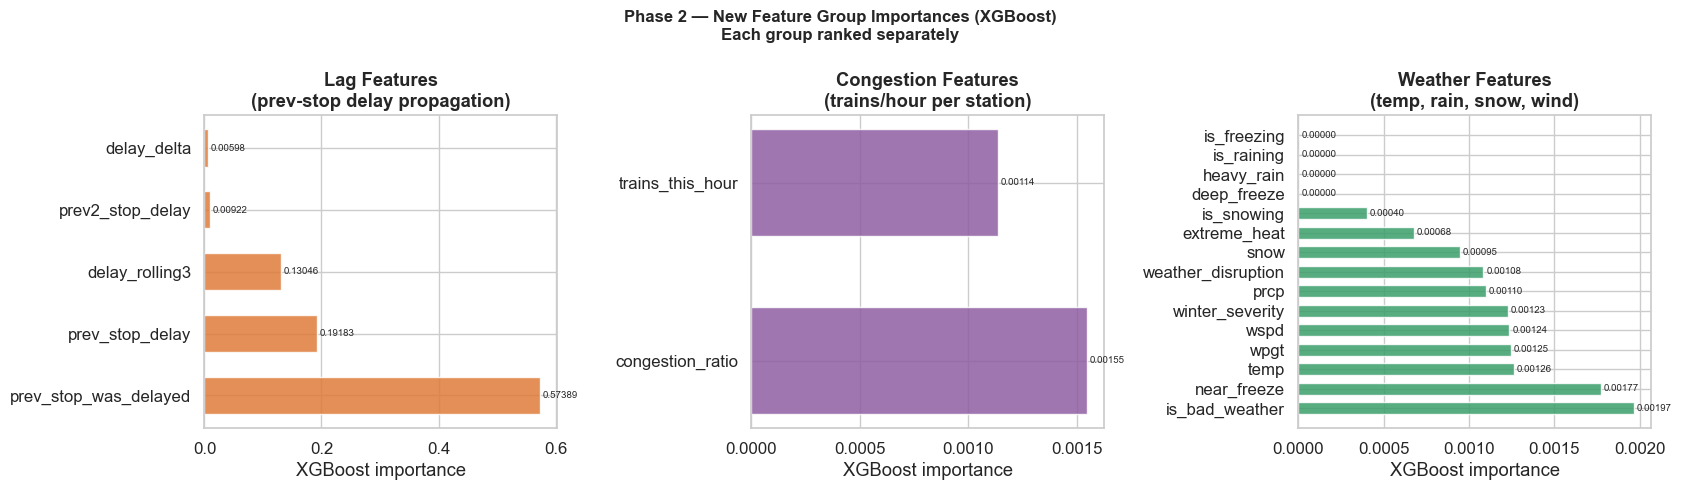

In [46]:
# ════════════════════════════════════════════════════════════
# CELL 19 · CHART 6 — Per-group importance zoom
# ════════════════════════════════════════════════════════════

lag_xgb  = xgb_imp[xgb_imp["feature"].isin(LAG_FEATURES)].copy()
cong_xgb = xgb_imp[xgb_imp["feature"].isin(CONGESTION_FEATURES)].copy()
wx_xgb   = xgb_imp[xgb_imp["feature"].isin(WEATHER_FEATURES)].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, df_i, title, clr in zip(
        axes,
        [lag_xgb, cong_xgb, wx_xgb],
        ["Lag Features\n(prev-stop delay propagation)",
         "Congestion Features\n(trains/hour per station)",
         "Weather Features\n(temp, rain, snow, wind)"],
        ["#e07b3a", "#8e5ea2", "#3a9e6a"]):
    if len(df_i) == 0:
        ax.text(0.5, 0.5, "No features\nin this group",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set_title(title, fontweight="bold"); continue
    bars = ax.barh(df_i["feature"], df_i["importance"],
                   color=clr, alpha=0.85, height=0.6)
    ax.bar_label(bars, fmt="%.5f", padding=2, fontsize=7)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("XGBoost importance")

plt.suptitle("Phase 2 — New Feature Group Importances (XGBoost)\n"
             "Each group ranked separately",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_06_group_importances.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

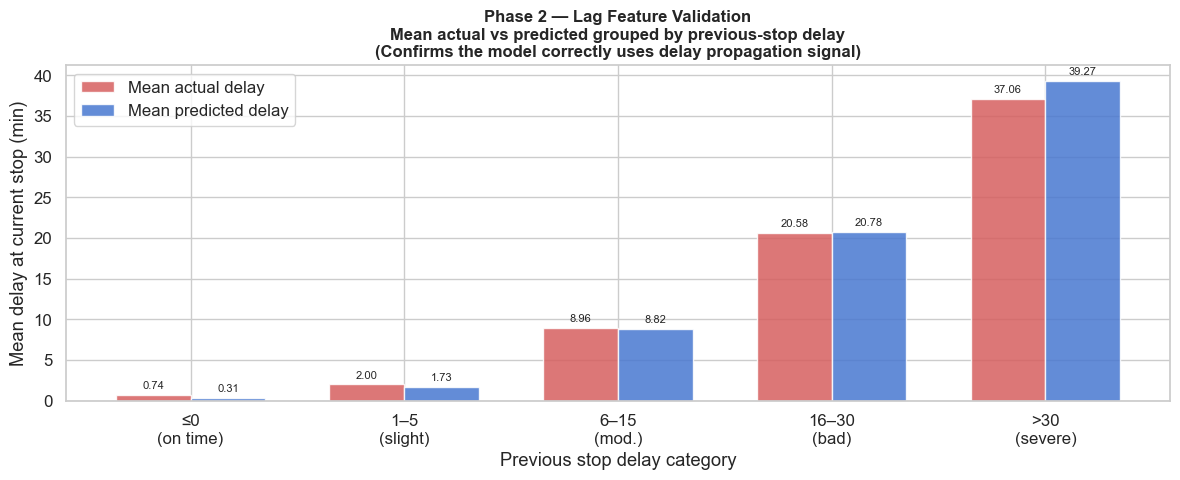

In [47]:
# ════════════════════════════════════════════════════════════
# CELL 20 · CHART 7 — Lag validation chart
# ════════════════════════════════════════════════════════════

if "prev_stop_delay" in df_test.columns:
    test_prev = df_test["prev_stop_delay"].values
    bins   = [-np.inf, 0, 5, 15, 30, np.inf]
    labels = ["≤0\n(on time)", "1–5\n(slight)", "6–15\n(mod.)",
              "16–30\n(bad)", ">30\n(severe)"]
    prev_bin = pd.cut(test_prev, bins=bins, labels=labels)

    bin_rows = []
    for lbl in labels:
        mask = prev_bin == lbl
        if mask.sum() > 20:
            bin_rows.append({
                "label"       : lbl,
                "actual_mean" : float(y_test[mask].mean()),
                "pred_mean"   : float(best_pred[mask].mean()),
                "n"           : int(mask.sum()),
            })
    bin_df = pd.DataFrame(bin_rows)

    x, w2 = np.arange(len(bin_df)), 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - w2/2, bin_df["actual_mean"], w2,
                   label="Mean actual delay",    color=PAL[3], alpha=0.85)
    bars2 = ax.bar(x + w2/2, bin_df["pred_mean"], w2,
                   label="Mean predicted delay", color=PAL[0], alpha=0.85)
    ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(bin_df["label"])
    ax.set_xlabel("Previous stop delay category")
    ax.set_ylabel("Mean delay at current stop (min)")
    ax.set_title("Phase 2 — Lag Feature Validation\n"
                 "Mean actual vs predicted grouped by previous-stop delay\n"
                 "(Confirms the model correctly uses delay propagation signal)",
                 fontsize=12, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p2_07_lag_validation.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
else:
    print("  prev_stop_delay not in test set — skipping lag validation chart")

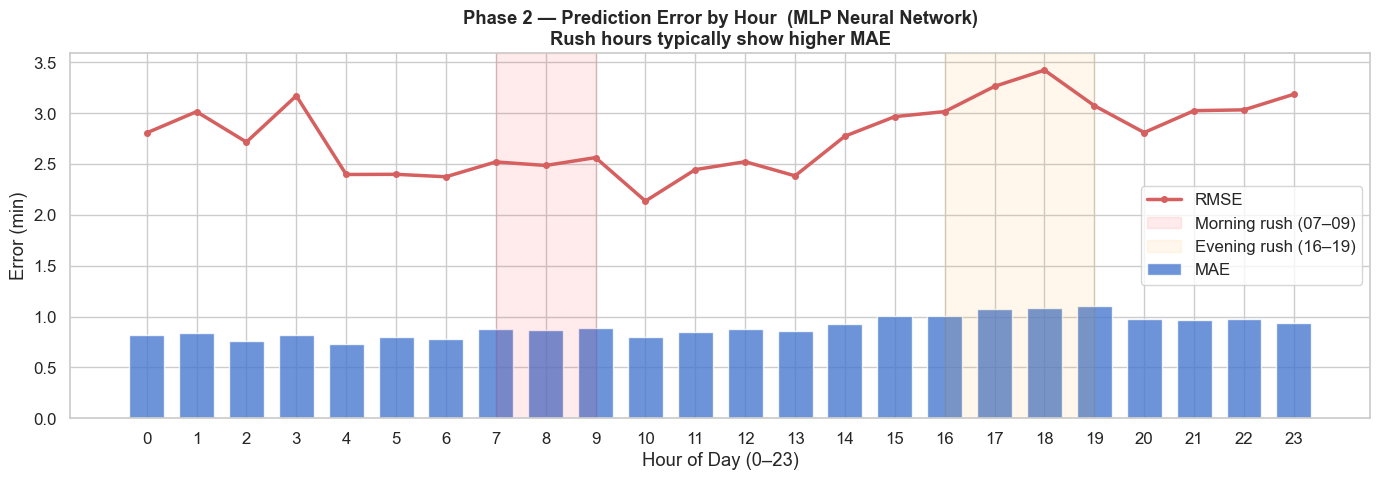

In [48]:
# ════════════════════════════════════════════════════════════
# CELL 21 · CHART 8 — MAE by hour of day
# ════════════════════════════════════════════════════════════

test_hrs = df_test["hour"].values
hr_rows  = []
for h in range(24):
    mask = test_hrs == h
    if mask.sum() > 100:
        hr_rows.append({
            "hour": h,
            "MAE" : mean_absolute_error(y_test[mask], best_pred[mask]),
            "RMSE": float(np.sqrt(mean_squared_error(y_test[mask], best_pred[mask]))),
        })
hr_df = pd.DataFrame(hr_rows)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hr_df["hour"], hr_df["MAE"],  color=PAL[0], alpha=0.8, width=0.7, label="MAE")
ax.plot(hr_df["hour"], hr_df["RMSE"], color=PAL[3], lw=2.5, marker="o", ms=4, label="RMSE")
ax.axvspan(7,  9,  alpha=0.08, color="red",    label="Morning rush (07–09)")
ax.axvspan(16, 19, alpha=0.08, color="orange", label="Evening rush (16–19)")
ax.set_xticks(range(24))
ax.set_xlabel("Hour of Day (0–23)"); ax.set_ylabel("Error (min)")
ax.set_title(f"Phase 2 — Prediction Error by Hour  ({best_name})\n"
             "Rush hours typically show higher MAE", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_08_mae_by_hour.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

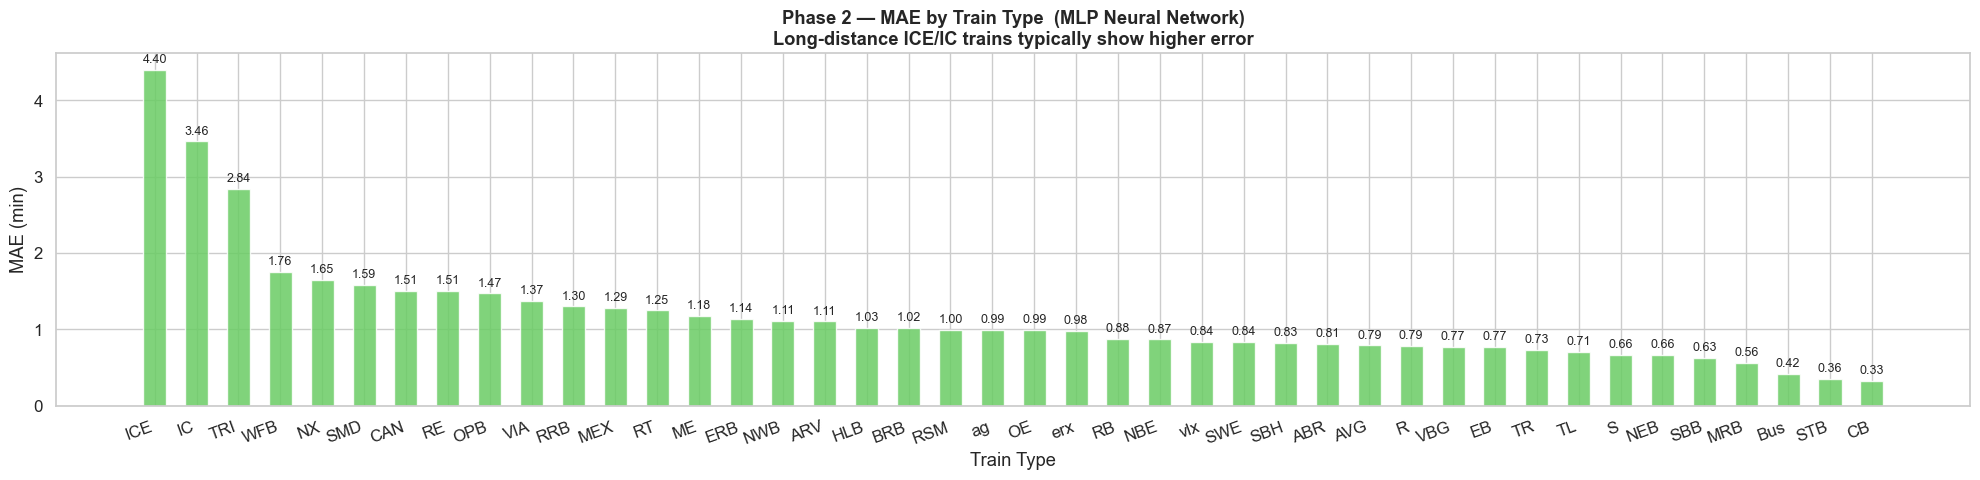

In [53]:
# ════════════════════════════════════════════════════════════
# CELL 22 · CHART 9 — MAE by train type
# ════════════════════════════════════════════════════════════

test_types = df_test["train_type"].values
type_rows  = []
for tt in sorted(np.unique(test_types)):
    mask = test_types == tt
    if mask.sum() > 200:
        type_rows.append({
            "train_type": tt,
            "MAE"       : mean_absolute_error(y_test[mask], best_pred[mask]),
            "n"         : int(mask.sum()),
        })
type_df = pd.DataFrame(type_rows).sort_values("MAE", ascending=False)

fig, ax = plt.subplots(figsize=(20, 5))
bars = ax.bar(type_df["train_type"], type_df["MAE"],
              color=PAL[2], alpha=0.85, width=0.55)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlabel("Train Type"); ax.set_ylabel("MAE (min)")
ax.set_title(f"Phase 2 — MAE by Train Type  ({best_name})\n"
             "Long-distance ICE/IC trains typically show higher error",
             fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_09_mae_by_train_type.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

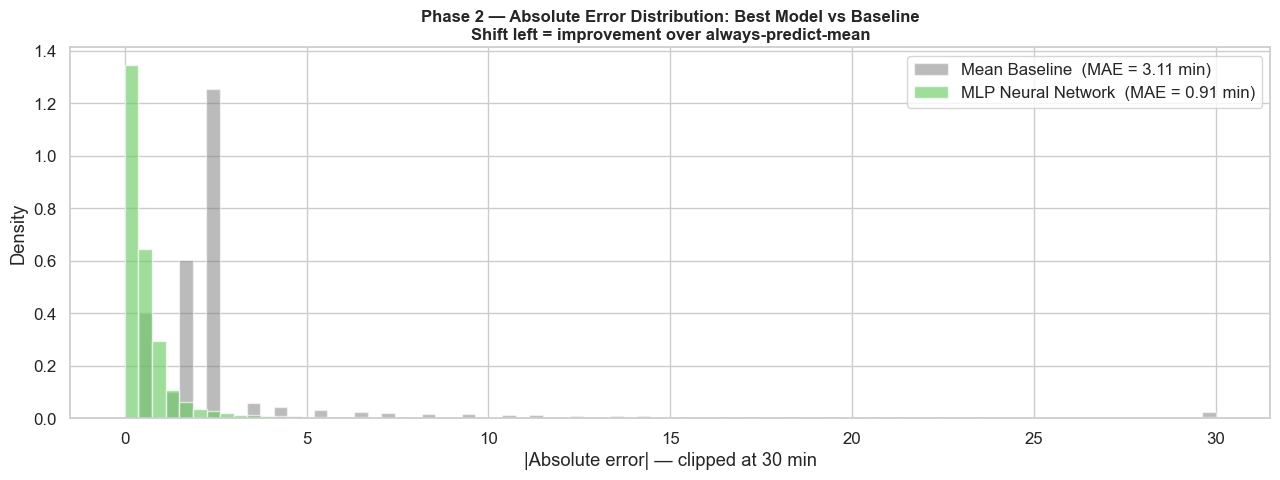


✅  All 10 Phase 2 charts saved to: outputs\figures


In [50]:
# ════════════════════════════════════════════════════════════
# CELL 23 · CHART 10 — Error distribution vs baseline
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(np.abs(pred_baseline - y_test).clip(0, 30),
        bins=80, alpha=0.50, density=True, color=PAL[7],
        label=f"Mean Baseline  (MAE = {m_baseline['MAE (min)']:.2f} min)")
ax.hist(np.abs(best_pred - y_test).clip(0, 30),
        bins=80, alpha=0.65, density=True, color=PAL[2],
        label=f"{best_name}  (MAE = {best_mae:.2f} min)")
ax.set_xlabel("|Absolute error| — clipped at 30 min")
ax.set_ylabel("Density")
ax.set_title("Phase 2 — Absolute Error Distribution: Best Model vs Baseline\n"
             "Shift left = improvement over always-predict-mean",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_10_error_vs_baseline.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"\n✅  All 10 Phase 2 charts saved to: {FIG_DIR}")

In [51]:
# ════════════════════════════════════════════════════════════
# CELL 24 · SAVE BEST MODEL & PREDICTIONS
# ════════════════════════════════════════════════════════════

model_map = {
    "Mean Baseline"    : None,
    "Linear Regression": pipe_lr,
    "Ridge Regression" : pipe_ridge,
    "Lasso Regression" : pipe_lasso,
    "Random Forest"    : rf,
    "XGBoost"          : xgb_model,
    "LightGBM"         : lgbm_model,
    "MLP Neural Network": mlp,
}

best_obj = model_map.get(best_name)
if best_name == "MLP Neural Network":
    mlp.save(str(MODEL_DIR / "p2_best_model.keras"))
elif best_obj is not None:
    joblib.dump(best_obj, MODEL_DIR / "p2_best_model.pkl")
print(f"Best model saved → outputs/models/p2_best_model.*")

keep_cols = ["departure_planned_time","station_name",
             "train_type","delay_class","delay_in_min"]
for extra in ["prev_stop_delay","weather_disruption",
              "trains_this_hour","congestion_ratio","train_line_ride_id"]:
    if extra in df_test.columns:
        keep_cols.append(extra)

pred_out = df_test[keep_cols].copy()
pred_out["predicted_delay"] = best_pred
pred_out["residual"]        = y_test - best_pred
pred_out.to_parquet(OUTPUT_DIR / "phase2_predictions.parquet", index=False)
print(f"Predictions saved → outputs/phase2_predictions.parquet")

phase2_cfg = {
    "best_model_name"    : best_name,
    "best_mae"           : best_mae,
    "best_r2"            : best_r2,
    "best_within_5min"   : best_w5,
    "FEATURES_TREE"      : FEATURES_TREE,
    "FEATURES_LINEAR"    : FEATURES_LINEAR,
    "WEATHER_FEATURES"   : WEATHER_FEATURES,
    "LAG_FEATURES"       : LAG_FEATURES,
    "CONGESTION_FEATURES": CONGESTION_FEATURES,
    "TARGET"             : TARGET,
    "LEAKAGE_COLS"       : LEAKAGE_COLS,
    "all_model_results"  : all_results,
    "split_strategy"     : "ride_based_GroupShuffleSplit",
    "early_stopping_val" : "train_internal_10pct",
}
with open(OUTPUT_DIR / "phase2_config.json", "w") as f:
    json.dump(phase2_cfg, f, indent=2)
print(f"Phase 2 config   → outputs/phase2_config.json")

Best model saved → outputs/models/p2_best_model.*
Predictions saved → outputs/phase2_predictions.parquet
Phase 2 config   → outputs/phase2_config.json


In [52]:
# ════════════════════════════════════════════════════════════
# CELL 25 · FINAL SUMMARY
# ════════════════════════════════════════════════════════════

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║        ✅  PHASE 2 COMPLETE — REGRESSION  (v4, honest)           ║
╠══════════════════════════════════════════════════════════════════╣
║  Models trained         : 8  (Baseline → MLP)                   ║
║  Best model             : {best_name:<40}  ║
║  MAE                    : {best_mae:.3f} min                           ║
║  R²                     : {best_r2:.4f}  ({best_r2*100:.1f}% variance explained) ║
║  Within 5 min           : {best_w5:.1f}%                              ║
║  Directional accuracy   : {best_dacc:.1f}%                            ║
║  Improvement vs baseline: {pct_improvement:.1f}%                            ║
╠══════════════════════════════════════════════════════════════════╣
║  Feature groups:                                                 ║
║    Temporal + Station + Type + Route + Geo                       ║
║    + Weather ({len(WEATHER_FEATURES)}) + Lag ({len(LAG_FEATURES)}) + Congestion ({len(CONGESTION_FEATURES)})                     ║
╠══════════════════════════════════════════════════════════════════╣
║  EVALUATION INTEGRITY:                                           ║
║    Split     : ride-based GroupShuffleSplit (zero ride overlap)  ║
║    ES valida.: train-internal 10% slice (NOT test set)           ║
║    Lag NaN   : first stop of each test ride → 0 (honest)         ║
╠══════════════════════════════════════════════════════════════════╣
║  Outputs:                                                        ║
║    outputs/phase2_results.csv                                    ║
║    outputs/phase2_predictions.parquet                            ║
║    outputs/phase2_config.json                                    ║
║    outputs/models/p2_best_model.*                                ║
║    outputs/figures/p2_00 … p2_10  (11 charts)                   ║
╠══════════════════════════════════════════════════════════════════╣
║  Next: Phase 3 → Classification  (predict delay_class 0–3)       ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║        ✅  PHASE 2 COMPLETE — REGRESSION  (v4, honest)           ║
╠══════════════════════════════════════════════════════════════════╣
║  Models trained         : 8  (Baseline → MLP)                   ║
║  Best model             : MLP Neural Network                        ║
║  MAE                    : 0.913 min                           ║
║  R²                     : 0.7547  (75.5% variance explained) ║
║  Within 5 min           : 97.2%                              ║
║  Directional accuracy   : 96.5%                            ║
║  Improvement vs baseline: 70.7%                            ║
╠══════════════════════════════════════════════════════════════════╣
║  Feature groups:                                                 ║
║    Temporal + Station + Type + Route + Geo                       ║
║    + Weather (15) + Lag (5) + Congestion (2)                     ║
╠══════════════════════════════════════════════════════